In [3153]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

In [3154]:
import random

random.seed(42)

In [3155]:
routes = pd.read_csv("../data/raw/route.csv")

In [3156]:
G = nx.DiGraph()

In [3157]:
# bus stops
stop_map = {
    # "หอพักเอเชียนเกม (B Zone)": "Dorm",
    "หอพักเอเชียนเกม": "Dorm",
    "green": "Green",
    "SC2 SC3": "SC2_SC3",
    "อาคารสุขศาสตร์": "Health",
    # "อาคารบรรยายรวม 4": "Lecture",
    "อาคารบรรยายรวม": "Lecture",
    "ศูนย์ประชุม": "Convention",
    "สถานีขนส่ง": "Terminal",
    "หอสมุดป๋วย": "Library",
    "รพ.ธรรมศาสตร์": "Hospital",
    "อุทยานการเรียนรู้ป๋วย 100 ปี": "Park",
    # "อาคารบรรยายรวม 3": "Lecture3",
    # "อาคารบรรยายรวม 1": "Lecture1",
    "TU DOME": "Dome",
    "ประตูเชียงราก 1": "Gate1",
    "SC1": "SC1",
    "อาคารเรียนรวมกลุ่มสังคมศาสตร์": "Social"
}

stops = list(set(stop_map.values()))
G.add_nodes_from(stops)


### Candidate Routes

In [3158]:
# Candidate Stops
candidate_stops = [
    "Dorm",
    "Green",
    "SC2_SC3",
    "Health",
    "Lecture"
] #ตอนนี้จำลองมาแค่ สายเสริมพิเศษ

### Convert KM to Minute

In [3159]:
def km_to_min(km):
    return round(km * 3)  # 20 km/h

# เสริมพิเศษ
G.add_edge("Dorm", "Green", weight=km_to_min(1.2))
G.add_edge("Green", "SC2_SC3", weight=km_to_min(0.6))
G.add_edge("SC2_SC3", "Health", weight=km_to_min(1.0))
G.add_edge("Health", "Lecture", weight=km_to_min(0.5))
G.add_edge("Lecture", "Dorm", weight=km_to_min(1.9))

# สีแดง 1A
G.add_edge("Convention", "Terminal", weight=km_to_min(1.1))
G.add_edge("Terminal", "SC2_SC3", weight=km_to_min(0.65))
G.add_edge("SC2_SC3", "Library", weight=km_to_min(0.6))
G.add_edge("Library", "Dorm", weight=km_to_min(1.5))
G.add_edge("Dorm", "Convention", weight=km_to_min(3.6))

# สีเหลือง 1B
G.add_edge("Convention", "Dorm", weight=km_to_min(3.6))
G.add_edge("Dorm", "Library", weight=km_to_min(1.5))
G.add_edge("Library", "SC2_SC3", weight=km_to_min(0.6))
G.add_edge("SC2_SC3", "Terminal", weight=km_to_min(0.65))
G.add_edge("Terminal", "Convention", weight=km_to_min(1.1))

# สีเขียว 2
G.add_edge("Convention", "Hospital", weight=km_to_min(0.7))
G.add_edge("Hospital", "Health", weight=km_to_min(0.5))
G.add_edge("Health", "Park", weight=km_to_min(0.1))
G.add_edge("Park", "Lecture", weight=km_to_min(0.28))
# G.add_edge("Lecture", "Lecture3", weight=km_to_min(0.22))
# G.add_edge("Lecture3", "Lecture1", weight=km_to_min(0.45))
G.add_edge("Lecture", "Convention", weight=3)  # สมมติ

# สีม่วง 3
G.add_edge("Dome", "Gate1", weight=3)
G.add_edge("Gate1", "SC1", weight=3)
G.add_edge("SC1", "Library", weight=3)
G.add_edge("Library", "Green", weight=3)
G.add_edge("Green", "Dorm", weight=3)

# สีฟ้า 5
G.add_edge("Convention", "Social", weight=3)
G.add_edge("Social", "Lecture", weight=3)
G.add_edge("Lecture", "Park", weight=3)
G.add_edge("Park", "Health", weight=3)
G.add_edge("Health", "Hospital", weight=3)

### Bidirectional

In [3160]:
edges = list(G.edges(data=True))

for u, v, data in edges:
    G.add_edge(v, u, weight=data["weight"])

In [3161]:
# Single Candidate Routes
# def generate_single_candidate_route(
#     graph,
#     start="Dorm",
#     min_length=4,
#     max_length=6
# ):
#     """
#     สร้าง route แบบ loop
#     start -> ... -> start
#     """
#     route = [start]
#     current = start
#     route_length = random.randint(min_length, max_length)

#     while len(route) < route_length:
#         neighbors = list(graph.neighbors(current))
#         # หลีกเลี่ยงการวนซ้ำมั่ว
#         valid_neighbors = [
#             n for n in neighbors
#             if n not in route[:-1]
#         ]

#         if not valid_neighbors:
#             break
#         next_stop = random.choice(valid_neighbors)
#         route.append(next_stop)
#         current = next_stop
#     # ปิด loop กลับจุดเริ่มต้น

#     if route[-1] != start:
#         if graph.has_edge(route[-1], start):
#             route.append(start)
#         else:
#             try:
#                 path_back = nx.shortest_path(
#                     graph,
#                     source=route[-1],
#                     target=start,
#                     weight="weight"
#                 )
#                 route.extend(path_back[1:])
#             except:
#                 route.append(start)
#     return route

In [3162]:
# MANY Candidate Routes
# def generate_candidate_routes(
#     graph,
#     num_routes=20
# ):
#     candidate_routes = []

#     important_stops = [

#         "Dorm",

#         "Lecture",

#         "Library",

#         "Convention",

#         "Terminal",

#         "Hospital"

#     ]

#     for i in range(num_routes):

#         start = random.choice(important_stops)

#         end = random.choice(important_stops)

#         while start == end:

#             end = random.choice(important_stops)

#         try:

#             path = nx.shortest_path(

#                 G,
#                 source=start,
#                 target=end,
#                 weight="weight"
#             )

#             # ทำให้เป็น loop route

#             if path[-1] != path[0]:

#                 path.append(path[0])

#             route = {

#                 "route_id": i + 1,

#                 "path": path,

#                 "cycle_time": len(path),

#             }

#             candidate_routes.append(route)

#         except:

#             continue

#     return candidate_routes

### Route for simulation

In [3163]:
route_special = ["Dorm", "Green", "SC2_SC3", "Health", "Lecture", "Dorm"]
route_red = ["Convention", "Terminal", "SC2_SC3", "Library", "Dorm", "Convention"]
route_yellow = ["Convention", "Dorm", "Library", "SC2_SC3", "Terminal", "Convention"]
route_purple = ["Dome", "Gate1", "SC1", "Library", "Green", "Dorm"]
route_blue = ["Convention", "Social", "Lecture", "Park", "Health", "Hospital"]
route_green = ["Convention", "Hospital", "Health", "Park", "Lecture", "Convention"]

In [3164]:
fixed_routes = [
    {
        "route_id": 1,
        "path": route_red
    },
    # {
    #     "route_id": 2,
    #     "path": route_yellow
    # },
    # {
    #     "route_id": 3,
    #     "path": route_green
    # },
    # {
    #     "route_id": 4,
    #     "path": route_purple
    # },
    # {
    #     "route_id": 5,
    #     "path": route_blue
    # },
    # {
    #     "route_id": 6,
    #     "path": route_special
    # }
]

In [3165]:
print("===== Candidate Routes =====")
for route in fixed_routes:
    print(f"{route["route_id"]}: {route["path"]}")

===== Candidate Routes =====
1: ['Convention', 'Terminal', 'SC2_SC3', 'Library', 'Dorm', 'Convention']


### Bus Object Class

In [3166]:
class Bus:
    def __init__(self, id, capacity, route):
        self.id = id
        self.capacity = capacity
        self.route = route
        self.current_index = 0   # อยู่ป้ายไหน
        self.passengers = []

### Define Buses

In [3167]:
buses = [
    Bus(0, 30, route_special),
    Bus(1, 30, route_red),
    Bus(2, 30, route_yellow),
    Bus(3, 30, route_purple),
    Bus(4, 30, route_blue),
    Bus(5, 30, route_green),
]

### Passenger Model

In [3168]:
class Passenger:
    def __init__(self, origin, destination, arrival_time):
        self.origin = origin
        self.destination = destination
        self.arrival_time = arrival_time

### Queue

In [3169]:
queues = {
    "Dorm": [],
    "Green": [],
    "SC2_SC3": [],
    "Health": [],
    "Lecture": [],
    "Terminal" : [],
    "Convention" : [],
    "Library" : [],
    "SC1" : [],
    "Gate1" : [],
    "Hospital" : [],
    "Social" : [],
    "Park" : [],
    "Dome" : []
}

In [3170]:
TOTAL_BUSES = 20          # รถรวมทั้งหมด
MIN_ROUTE_BUS = [1, 1, 1, 1, 1, 1]   # route 0 ต้องมีอย่างน้อย 1 คัน
MAX_PER_ROUTE = 5
MIN_PER_ROUTE = 1
SELECTED_ROUTES = 1 

In [3171]:
# def repair(chromosome):
#     used = set()
#     repaired = []
#     for gene in chromosome:
#         rid = gene["route_id"]
#         if rid not in used:
#             used.add(rid)
#             repaired.append({
#                 "route_id": rid,
#                 "path": gene["path"],  # สำคัญมาก
#                 "num_bus": MAX_PER_ROUTE
#             })
#     # ---------------------------------
#     # 2. route ไม่ครบ → เติมเพิ่ม
#     # ---------------------------------
#     available_routes = [
#         route for route in fixed_routes
#         if route["route_id"] not in used
#     ]
#     while len(repaired) < SELECTED_ROUTES:
#         route = random.choice(
#             available_routes
#         )
#         available_routes.remove(route)
#         repaired.append({
#             "route_id": route["route_id"],
#             "path": route["path"],   # สำคัญมาก
#             "num_bus": MIN_PER_ROUTE
#         })
#     # ---------------------------------
#     # 3. route เกิน → ตัดออก
#     # ---------------------------------
#     while len(repaired) > SELECTED_ROUTES:
#         repaired.pop()
#     # ---------------------------------
#     # 4. total buses = TOTAL_BUSES
#     # ---------------------------------
#     current_total = sum(
#         g["num_bus"]
#         for g in repaired
#     )
#     while current_total < TOTAL_BUSES:
#         idx = random.randint(0,len(repaired) - 1)
#         if repaired[idx]["num_bus"] < MAX_PER_ROUTE:
#             repaired[idx]["num_bus"] += 1
#             current_total += 1
#     while current_total > TOTAL_BUSES:
#         idx = random.randint(0,len(repaired) - 1)
#         if repaired[idx]["num_bus"] > MIN_PER_ROUTE:
#             repaired[idx]["num_bus"] -= 1
#             current_total -= 1
#     return repaired

def repair(chromosome):
    used = set()
    repaired = []

    for gene in chromosome:
        rid = gene["route_id"]

        if rid not in used:
            used.add(rid)

            repaired.append({
                "route_id": rid,
                "path": gene["path"],
                "num_bus": 5   # fix จำนวนรถ
            })

    return repaired

In [3172]:
# def random_chromosome():
#     # สุ่มเลือก route จริงจาก candidate_routes
#     selected_routes = fixed_routes
#     chromosome = []
    
#     for route in selected_routes:
#         chromosome.append({
#             "route_id": route["route_id"],
#             # สำคัญมาก
#             "path": route["path"],
#             "num_bus": 5
#             # random.randint(
#             #     MIN_PER_ROUTE,
#             #     MAX_PER_ROUTE
#             # )
#         })
#     chromosome = repair(chromosome)
#     return chromosome

def random_chromosome():
    selected_routes = fixed_routes
    chromosome = []

    for route in selected_routes:
        chromosome.append({
            "route_id": route["route_id"],
            "path": route["path"],
            "num_bus": 5
        })
    return repair(chromosome)

In [3173]:
def calculate_cycle_time(route_path, graph):
    """
    คำนวณเวลาเดินทางรวมของ route
    โดยใช้ weight จาก graph
    """
    total_time = 0
    for i in range(len(route_path) - 1):
        current_stop = route_path[i]
        next_stop = route_path[i + 1]
        try:
            edge_time = graph[current_stop][next_stop]["weight"]
            total_time += edge_time
        except:
            # ถ้าไม่มี edge โดยตรง
            # ใช้ shortest path แทน
            try:

                shortest_time = nx.shortest_path_length(

                    graph,

                    source=current_stop,

                    target=next_stop,

                    weight="weight"

                )

                total_time += shortest_time

            except:

                # กัน graph error

                total_time += 999

    return total_time

# def build_active_routes(chromosome, fixed_routes, graph):
#     active_routes = []

#     for gene in chromosome:
#         route_id = gene["route_id"]
#         num_bus = 5
#         # num_bus = gene["num_bus"]

#         # หา route จาก candidate_routes
#         route_data = next(
#             (
#                 r for r in fixed_routes
#                 if r["route_id"] == route_id
#             ),
#             None
#         )

#         # ถ้าไม่เจอ → ข้าม
#         if route_data is None:
#             print(f"WARNING: route_id {route_id} not found")
#             continue

#         route_path = route_data["path"]

#         cycle_time = calculate_cycle_time(
#             route_path,
#             graph
#         )

#         headway = cycle_time / num_bus

#         active_routes.append({
#             "route_id": route_id,
#             "path": route_path,
#             "num_bus": num_bus,
#             "cycle_time": cycle_time,
#             "headway": round(headway, 2)
#         })

#     return active_routes
      

# # =========================================

# # TEST

# # =========================================

# print("===== ACTIVE ROUTES =====")

# # random chromosome จาก STEP 2

# test_chromosome = random_chromosome()

# active_routes = build_active_routes(

#     test_chromosome,

#     fixed_routes,

#     G

# )

# for route in active_routes:

#     print(route)

### Simulation Loop

In [3174]:
import random

def run_simulation(active_routes, stops, simulation_time=60):

    # =====================================
    # RESET STATE
    # =====================================

    queues = {stop: [] for stop in stops}

    waiting_times = []
    travel_times = []
    queue_lengths = []

    buses = []
    bus_id = 0

    # =====================================
    # CREATE BUSES FROM ACTIVE ROUTES
    # =====================================

    for route_info in active_routes:
        route_path = route_info["path"]
        num_bus = 5

        for _ in range(num_bus):
            buses.append(
                Bus(
                    id=bus_id,
                    capacity=30,
                    route=route_path
                )
            )
            bus_id += 1

    # =====================================
    # PASSENGER GENERATION
    # =====================================

    def generate_passengers(t):

        # Peak Time Example
        if 10 <= t <= 25:
            demand_prob = 0.8
        else:
            demand_prob = 0.4

        if random.random() < demand_prob:
            origin = random.choice(stops)
            destination = random.choice(stops)

            while destination == origin:
                destination = random.choice(stops)

            p = Passenger(
                origin=origin,
                destination=destination,
                arrival_time=t
            )

            queues[origin].append(p)

    # =====================================
    # MOVE BUS
    # =====================================

    def move_bus(bus):
        bus.current_index += 1

        if bus.current_index >= len(bus.route):
            bus.current_index = 0

    # =====================================
    # DROP PASSENGERS
    # =====================================

    def drop_passengers(bus, t):
        current_stop = bus.route[bus.current_index]

        remaining = []

        for p in bus.passengers:
            if p.destination == current_stop:
                p.drop_time = t

                travel_time = t - p.arrival_time
                travel_times.append(travel_time)

            else:
                remaining.append(p)

        bus.passengers = remaining

    # =====================================
    # BOARD PASSENGERS
    # =====================================

    def board_passengers(bus, t):
        current_stop = bus.route[bus.current_index]

        if current_stop not in queues:
            return

        queue = queues[current_stop]

        remaining_queue = []

        for p in queue:
            if (
                len(bus.passengers) < bus.capacity
                and p.destination in bus.route
            ):
                p.board_time = t
                bus.passengers.append(p)

                waiting_time = t - p.arrival_time
                waiting_times.append(waiting_time)

            else:
                remaining_queue.append(p)

        queues[current_stop] = remaining_queue

    # =====================================
    # MAIN SIMULATION LOOP
    # =====================================

    for t in range(simulation_time):

        generate_passengers(t)

        for bus in buses:
            move_bus(bus)
            drop_passengers(bus, t)
            board_passengers(bus, t)

        total_queue = sum(len(q) for q in queues.values())
        queue_lengths.append(total_queue)

    # =====================================
    # METRICS
    # =====================================

    avg_wait = (
        sum(waiting_times) / len(waiting_times)
        if waiting_times else 0
    )

    avg_travel = (
        sum(travel_times) / len(travel_times)
        if travel_times else 0
    )

    avg_queue_length = (
        sum(queue_lengths) / len(queue_lengths)
        if queue_lengths else 0
    )

    return {
        "avg_wait_time": round(avg_wait, 2),
        "avg_travel_time": round(avg_travel, 2),
        "avg_queue_length": round(avg_queue_length, 2),
        "served_passengers": len(travel_times)
    }

In [3175]:
# routes_test = [
#     {'route_id': 1, 'path': ['Convention', 'Terminal', 'SC2_SC3', 'Library', 'Dorm', 'Convention'], 'num_bus': 4, 'cycle_time': 22, 'headway': 5.5},
#     {'route_id': 2, 'path': ['Convention', 'Dorm', 'Library', 'SC2_SC3', 'Terminal', 'Convention'], 'num_bus': 1, 'cycle_time': 22, 'headway': 22.0},
#     {'route_id': 3, 'path': ['Convention', 'Hospital', 'Health', 'Park', 'Lecture', 'Convention'], 'num_bus': 3, 'cycle_time': 11, 'headway': 3.67},
#     {'route_id': 4, 'path': ['Dome', 'Gate1', 'SC1', 'Library', 'Green', 'Dorm'], 'num_bus': 3, 'cycle_time': 15, 'headway': 5.0},
#     {'route_id': 5, 'path': ['Convention', 'Social', 'Lecture', 'Park', 'Health', 'Hospital'], 'num_bus': 4, 'cycle_time': 12, 'headway': 3.0},
#     {'route_id': 6, 'path': ['Dorm', 'Green', 'SC2_SC3', 'Health', 'Lecture', 'Dorm'], 'num_bus': 5, 'cycle_time': 16, 'headway': 3.2}
# ]

stops = [
    "Dorm","Green","SC2_SC3","Terminal","Convention","Library"
]

result = run_simulation(fixed_routes, stops)

print(result)

{'avg_wait_time': 2.28, 'avg_travel_time': 5.11, 'avg_queue_length': 6.65, 'served_passengers': 18}


In [3176]:
wait = result["avg_wait_time"]
travel = result["avg_travel_time"]
# queue = result["avg_queue_length"]
# served = result["served_passengers"]

norm_wait = wait / 10
norm_travel = travel / 10
# norm_queue = queue / 20
# norm_served = served / 20

before_score = (
     0.3 * norm_wait
        + 0.7 * norm_travel
        # + 0.20 * norm_queue
        # - 1.0 * norm_served
)
print(before_score)

0.4260999999999999


## Genetic Algorithm (GA)

In [3177]:
# Initial GA Params
POPULATION_SIZE = 20
ELITE_SIZE = 2
CROSSOVER_RATE = 0.8
MUTATION_RATE = 0.1
GENERATIONS = 30

In [3178]:
# print("===== RANDOM CHROMOSOME =====")

# ch = random_chromosome()

# for gene in ch:
#     # rid = gene["route_id"]
#     # buses = 5
#     # route_data = next(
#     #     r for r in fixed_routes
#     #     if r["route_id"] == rid
#     # )

#     print(
#         f"Route ID: {gene['route_id']} | "
#         f"Num Bus: {gene['num_bus']} | "
#         f"Path: {gene['path']}"
#     )

# print()
# print("Total Buses =", sum(
#     g["num_bus"] for g in ch
# ))

def random_chromosome():
    chromosome = []
    for route in fixed_routes:
        chromosome.append({
            "route_id": route["route_id"],
            "path": route["path"],
            "num_bus": 5
        })
    return chromosome

## รันรอบเดียว

In [3179]:
def fitness(chromosome, routes, stops):

    # constraint: จำนวนรถต้องเท่ากัน
    # if sum(chromosome) != TOTAL_BUSES:
    #     return 999999

    result = run_simulation(
        chromosome,
        routes,
        stops
    )

    wait = result["avg_wait_time"]
    travel = result["avg_travel_time"]
    # queue = result["avg_queue_length"]
    # served = result["served_passengers"]

    # hard constraint

    # if served < 8:
    #     return 999999

    # normalize

    norm_wait = wait / 10
    norm_travel = travel / 10
    # norm_queue = queue / 20
    # norm_served = served / 20
    # สูตรเดียวกันทั้งหมด

    score = (
        0.3 * norm_wait
        + 0.7 * norm_travel
        # + 0.20 * norm_queue
        # - 1.00 * norm_served
    )

    return score

In [3180]:
def tournament_selection(population, scores, k=3):
    selected = random.sample(list(zip(population, scores)), k)
    selected.sort(key=lambda x: x[1])  # lower = better
    return selected[0][0]

In [3181]:
def crossover(p1, p2):
    if len(p1) == 1:
        return repair([gene.copy() for gene in p1])
    
    point = random.randint( 1, len(p1) - 1)

    child = ( [gene.copy() for gene in p1[:point]] +
        [gene.copy() for gene in p2[point:]]
    )
    return repair(child)

In [3182]:
# def mutation(chromosome, mutation_rate=0.1):
#     child = [
#         {
#             "route_id": gene["route_id"],
#             "path": gene["path"],
#             "num_bus": gene["num_bus"]
#         }
#         for gene in chromosome
#     ]

#     if random.random() < mutation_rate:
#         i = random.randint(0, len(child) - 1)
#         j = random.randint(0, len(child) - 1)
#         while i == j:
#             j = random.randint(0, len(child) - 1)
#         # ลด route i
#         if child[i]["num_bus"] > MIN_PER_ROUTE:
#             child[i]["num_bus"] -= 1
#             # เพิ่ม route j
#             if child[j]["num_bus"] < MAX_PER_ROUTE:
#                 child[j]["num_bus"] += 1
#             else:
#                 # rollback
#                 child[i]["num_bus"] += 1

#     return repair(child)

def mutation(chromosome, mutation_rate):
    child = [gene.copy() for gene in chromosome]
    if random.random() > mutation_rate:
        return child

    # ถ้ามี route เดียว → เปลี่ยน path ใหม่
    idx = random.randint(0, len(child) - 1)
    current_route_id = child[idx]["route_id"]

    # หา route อื่นที่ไม่ใช่อันเดิม

    available_routes = [
        route for route in fixed_routes
        if route["route_id"] != current_route_id
    ]

    if not available_routes:
        return child
    new_route = random.choice(available_routes)

    child[idx] = {
        "route_id": new_route["route_id"],
        "path": new_route["path"],
        "num_bus": 5
    }
    return repair(child)

In [3183]:
def evaluate(chromosome, runs=5):
    scores = []

    for _ in range(runs):
        active_routes = []

        for gene in chromosome:
            route_id = gene["route_id"]
            route_path = gene["path"]
            num_bus = 5

            cycle_time = calculate_cycle_time(
                route_path,
                G
            )
            headway = cycle_time / num_bus

            active_routes.append({
                "route_id": route_id,
                "path": route_path,
                "num_bus": num_bus,
                "cycle_time": cycle_time,
                "headway": round(headway, 2)
            })

        result = run_simulation(
            active_routes,
            stops
        )

        wait = result["avg_wait_time"]
        travel = result["avg_travel_time"]
        # queue = result["avg_queue_length"]
        # served = result["served_passengers"]

        # hard constraint

        # if served < 8:
        #     scores.append(999999)
            # continue

        # normalize

        norm_wait = wait / 10
        norm_travel = travel / 10
        # norm_queue = queue / 20
        # norm_served = served / 20

        # สูตรเดียวกัน
        score = (
            0.3 * norm_wait
            + 0.7 * norm_travel
            # + 0.20 * norm_queue
            # - 1.00 * norm_served
        )
        scores.append(score)
    return sum(scores) / len(scores)

In [3184]:
def attach_route_details(solution, candidate_routes):
    final_solution = []

    for item in solution:
        rid = item["route_id"]
        num_bus = item["num_bus"]

        # หา route จริง
        route_data = None

        for route in candidate_routes:
            if route["route_id"] == rid:
                route_data = route.copy()
                break

        if route_data is None:
            continue

        # update จำนวนรถ
        route_data["num_bus"] = num_bus

        # คำนวณ headway ใหม่
        # route_data["headway"] = (
        #     route_data["cycle_time"] / num_bus
        #     if num_bus > 0 else float("inf")
        # )

        final_solution.append(route_data)

    return final_solution

In [3185]:
def run_ga(
    candidate_routes,
    stops,
    population_size=POPULATION_SIZE,
    generations=GENERATIONS,
    mutation_rate=MUTATION_RATE,
    crossover_rate=CROSSOVER_RATE,
    elite_size=ELITE_SIZE
):
    # =====================================
    # INITIAL POPULATION
    # =====================================

    population = [
        random_chromosome()
        for _ in range(population_size)
    ]

    best_history = []

    # =====================================
    # MAIN LOOP
    # =====================================

    for gen in range(generations):

        # evaluate ทุก chromosome
        scores = [
            evaluate(ch, runs=5)
            for ch in population
        ]

        # sort จากดีที่สุด → แย่สุด
        sorted_pairs = sorted(
            zip(scores, population),
            key=lambda x: x[0]
        )

        population = [x[1] for x in sorted_pairs]
        scores = [x[0] for x in sorted_pairs]

        best = population[0]
        best_score = scores[0]

        best_history.append(best_score)

        print(
            f"Gen {gen} | "
            f"Best: {best} | "
            f"Score: {best_score:.2f}"
        )

        # =====================================
        # ELITISM
        # =====================================

        new_population = population[:elite_size]

        # =====================================
        # CREATE NEXT GENERATION
        # =====================================

        while len(new_population) < population_size:

            # parent selection
            parent1 = tournament_selection(
                population,
                scores
            )

            parent2 = tournament_selection(
                population,
                scores
            )

            # crossover
            if random.random() < crossover_rate:
                child = crossover(parent1, parent2)
            else:
                child = parent1.copy()

            # mutation
            child = mutation(
                child,
                mutation_rate
            )

            # repair constraint
            child = repair(child)

            new_population.append(child)

        population = new_population

    # =====================================
    # FINAL RESULT
    # =====================================

    final_scores = [
        evaluate(ch, runs=5)
        for ch in population
    ]

    sorted_pairs = sorted(
        zip(final_scores, population),
        key=lambda x: x[0]
    )

    best_solution = sorted_pairs[0][1]
    best_score = sorted_pairs[0][0]

    best_solution_full = attach_route_details(best_solution,candidate_routes)

    return best_solution_full, best_score, best_history

In [3186]:
all_scores = []

best_GA, score_GA, history_GA = run_ga(fixed_routes, stops)
all_scores.append(score_GA)

avg_score = sum(all_scores) / len(all_scores)

print("Best:", best_GA)
print("Score:", score_GA)

Gen 0 | Best: [{'route_id': 1, 'path': ['Convention', 'Terminal', 'SC2_SC3', 'Library', 'Dorm', 'Convention'], 'num_bus': 5}] | Score: 0.41
Gen 1 | Best: [{'route_id': 1, 'path': ['Convention', 'Terminal', 'SC2_SC3', 'Library', 'Dorm', 'Convention'], 'num_bus': 5}] | Score: 0.38
Gen 2 | Best: [{'route_id': 1, 'path': ['Convention', 'Terminal', 'SC2_SC3', 'Library', 'Dorm', 'Convention'], 'num_bus': 5}] | Score: 0.40
Gen 3 | Best: [{'route_id': 1, 'path': ['Convention', 'Terminal', 'SC2_SC3', 'Library', 'Dorm', 'Convention'], 'num_bus': 5}] | Score: 0.40
Gen 4 | Best: [{'route_id': 1, 'path': ['Convention', 'Terminal', 'SC2_SC3', 'Library', 'Dorm', 'Convention'], 'num_bus': 5}] | Score: 0.41
Gen 5 | Best: [{'route_id': 1, 'path': ['Convention', 'Terminal', 'SC2_SC3', 'Library', 'Dorm', 'Convention'], 'num_bus': 5}] | Score: 0.40
Gen 6 | Best: [{'route_id': 1, 'path': ['Convention', 'Terminal', 'SC2_SC3', 'Library', 'Dorm', 'Convention'], 'num_bus': 5}] | Score: 0.38
Gen 7 | Best: [{'rou

### Sealing Anneal (SA)

In [3187]:
# def neighbor(solution):
#     # deep copy กัน dict โดนแก้ตรง ๆ
#     new_sol = [gene.copy() for gene in solution]

#     i = random.randint(0, len(new_sol) - 1)
#     j = random.randint(0, len(new_sol) - 1)

#     while i == j:
#         j = random.randint(0, len(new_sol) - 1)

#     # ลด route i ได้ก็ต่อเมื่อยังไม่ต่ำกว่า min
#     if new_sol[i]["num_bus"] > MIN_PER_ROUTE:

#         new_sol[i]["num_bus"] -= 1

#         # เพิ่ม route j ได้ก็ต่อเมื่อยังไม่เกิน max
#         if new_sol[j]["num_bus"] < MAX_PER_ROUTE:
#             new_sol[j]["num_bus"] += 1
#         else:
#             # rollback ถ้า route j เกิน max
#             new_sol[i]["num_bus"] += 1

#     return repair(new_sol)

def neighbor(solution):

    # deep copy

    new_sol = [gene.copy() for gene in solution]

    # เลือก route ที่จะ mutate

    idx = random.randint(0, len(new_sol) - 1)

    current_route_id = new_sol[idx]["route_id"]

    # หา route อื่นที่ไม่ใช่อันเดิม

    available_routes = [

        route for route in fixed_routes

        if route["route_id"] != current_route_id

    ]

    if not available_routes:

        return new_sol

    # สุ่ม route ใหม่

    new_route = random.choice(available_routes)

    new_sol[idx] = {

        "route_id": new_route["route_id"],

        "path": new_route["path"],

        "num_bus": 5

    }

    return repair(new_sol)

In [3188]:
import math

def accept(old_score, new_score, T):
    if new_score < old_score:
        return True

    prob = math.exp((old_score - new_score) / T)
    return random.random() < prob

In [3189]:
def run_sa(routes, stops,
           max_iter=200,
           T_init=10,
           cooling_rate=0.95):

    num_routes = len(routes)

    # 🔹 initial solution
    current = random_chromosome()
    current_score = evaluate(current, runs=5)

    best = current
    best_score = current_score

    T = T_init

    history = []

    for i in range(max_iter):

        # 🔹 สร้างเพื่อนบ้าน
        new_sol = neighbor(current)
        new_score = evaluate(new_sol, runs=5)

        # 🔹 accept หรือไม่
        if accept(current_score, new_score, T):
            current = new_sol
            current_score = new_score

        # 🔹 update best
        if current_score < best_score:
            best = current
            best_score = current_score

        history.append(best_score)

        print(f"Iter {i} | Best: {best} | Score: {best_score:.2f} | T={T:.2f}")

        # 🔹 ลดอุณหภูมิ
        T *= cooling_rate

        if T < 0.001:
            break

    return best, best_score, history

In [3190]:
best_SA, score_SA, history_SA = run_sa(fixed_routes, stops)

print("Best:", best_SA)
print("Score:", score_SA)

Iter 0 | Best: [{'route_id': 1, 'path': ['Convention', 'Terminal', 'SC2_SC3', 'Library', 'Dorm', 'Convention'], 'num_bus': 5}] | Score: 0.44 | T=10.00
Iter 1 | Best: [{'route_id': 1, 'path': ['Convention', 'Terminal', 'SC2_SC3', 'Library', 'Dorm', 'Convention'], 'num_bus': 5}] | Score: 0.44 | T=9.50
Iter 2 | Best: [{'route_id': 1, 'path': ['Convention', 'Terminal', 'SC2_SC3', 'Library', 'Dorm', 'Convention'], 'num_bus': 5}] | Score: 0.44 | T=9.03
Iter 3 | Best: [{'route_id': 1, 'path': ['Convention', 'Terminal', 'SC2_SC3', 'Library', 'Dorm', 'Convention'], 'num_bus': 5}] | Score: 0.44 | T=8.57
Iter 4 | Best: [{'route_id': 1, 'path': ['Convention', 'Terminal', 'SC2_SC3', 'Library', 'Dorm', 'Convention'], 'num_bus': 5}] | Score: 0.43 | T=8.15
Iter 5 | Best: [{'route_id': 1, 'path': ['Convention', 'Terminal', 'SC2_SC3', 'Library', 'Dorm', 'Convention'], 'num_bus': 5}] | Score: 0.43 | T=7.74
Iter 6 | Best: [{'route_id': 1, 'path': ['Convention', 'Terminal', 'SC2_SC3', 'Library', 'Dorm', 'C

### Particle Swarm OPtimization (PSO)

In [3191]:
class Particle:
    def __init__(self, num_routes):
        self.position = [random.uniform(0, 5) for _ in range(num_routes)]
        self.velocity = [random.uniform(-1, 1) for _ in range(num_routes)]

        self.best_position = self.position.copy()
        self.best_score = float("inf")

In [3192]:
def discretize(position):

    solution = []

    for i, x in enumerate(position):
        solution.append({
            "route_id": fixed_routes[i]["route_id"],
            # สำคัญมาก
            "path": fixed_routes[i]["path"],
            "num_bus": round(x)
        })
    return repair(solution)

In [3193]:
def run_pso(routes, stops,
            num_particles=20,
            max_iter=50,
            w=0.5, c1=1.5, c2=1.5):

    num_routes = len(routes)

    particles = [Particle(num_routes) for _ in range(num_particles)]

    global_best = None
    global_best_score = float("inf")

    history = []

    for it in range(max_iter):

        for p in particles:

            # 🔹 แปลงเป็น integer ก่อน evaluate
            discrete_sol = discretize(p.position)

            score = evaluate(discrete_sol, runs=5)

            # 🔹 update personal best
            if score < p.best_score:
                p.best_score = score
                p.best_position = p.position.copy()

            # 🔹 update global best
            if score < global_best_score:
                global_best_score = score
                global_best = p.position.copy()

        # 🔹 update velocity + position
        for p in particles:
            for i in range(num_routes):

                r1 = random.random()
                r2 = random.random()

                cognitive = c1 * r1 * (p.best_position[i] - p.position[i])
                social = c2 * r2 * (global_best[i] - p.position[i])

                p.velocity[i] = w * p.velocity[i] + cognitive + social
                p.position[i] += p.velocity[i]

        history.append(global_best_score)

        print(f"Iter {it} | Best Score: {global_best_score:.2f}")

    best_solution = discretize(global_best)

    return best_solution, global_best_score, history

In [3194]:
best_PSO, score_PSO, history_PSO = run_pso(fixed_routes, stops)

print("Best:", best_PSO)
print("Score:", score_PSO)

Iter 0 | Best Score: 0.41
Iter 1 | Best Score: 0.40
Iter 2 | Best Score: 0.37
Iter 3 | Best Score: 0.37
Iter 4 | Best Score: 0.37
Iter 5 | Best Score: 0.37
Iter 6 | Best Score: 0.37
Iter 7 | Best Score: 0.37
Iter 8 | Best Score: 0.37
Iter 9 | Best Score: 0.37
Iter 10 | Best Score: 0.37
Iter 11 | Best Score: 0.37
Iter 12 | Best Score: 0.37
Iter 13 | Best Score: 0.37
Iter 14 | Best Score: 0.37
Iter 15 | Best Score: 0.37
Iter 16 | Best Score: 0.37
Iter 17 | Best Score: 0.37
Iter 18 | Best Score: 0.37
Iter 19 | Best Score: 0.37
Iter 20 | Best Score: 0.37
Iter 21 | Best Score: 0.37
Iter 22 | Best Score: 0.37
Iter 23 | Best Score: 0.37
Iter 24 | Best Score: 0.37
Iter 25 | Best Score: 0.37
Iter 26 | Best Score: 0.37
Iter 27 | Best Score: 0.37
Iter 28 | Best Score: 0.37
Iter 29 | Best Score: 0.37
Iter 30 | Best Score: 0.37
Iter 31 | Best Score: 0.37
Iter 32 | Best Score: 0.37
Iter 33 | Best Score: 0.37
Iter 34 | Best Score: 0.37
Iter 35 | Best Score: 0.37
Iter 36 | Best Score: 0.37
Iter 37 | B

### Ant Colony Optimization (ACO)

In [3195]:
def heuristic(num_routes):
    return [1.0] * num_routes

In [3196]:
def construct_solution(pheromone,heuristic,total_buses,alpha,beta):
    num_routes = len(pheromone)

    solution = []

    for i in range(num_routes):
        route = fixed_routes[i]
        solution.append({
            "route_id": route["route_id"],
            "path": route["path"],
            "num_bus": MAX_PER_ROUTE
        })
    # =====================================

    # bus ที่เหลือต้องแจกเพิ่ม

    # =====================================

    remain = TOTAL_BUSES - (MIN_PER_ROUTE * num_routes)

    for _ in range(remain):
        probs = []
        for i in range(num_routes):
            # route นี้เต็มแล้ว
            if solution[i]["num_bus"] >= MAX_PER_ROUTE:
                probs.append(0)
                continue
            p = (
                (pheromone[i] ** alpha)
                *
                (heuristic[i] ** beta)
            )
            probs.append(p)

        # =====================================

        # normalize

        # =====================================

        s = sum(probs)
        if s == 0:
            break
        probs = [ p / s for p in probs ]

        # =====================================

        # roulette wheel selection

        # =====================================

        r = random.random()
        cum = 0

        for i in range(num_routes):
            cum += probs[i]
            if r <= cum:
                solution[i]["num_bus"] += 1
                break

    return repair(solution)

In [3197]:
def update_pheromone(pheromone,ants,scores,evaporation=0.5):
    # evaporation

    pheromone = [
        p * (1 - evaporation)
        for p in pheromone
    ]

    # deposit pheromone

    for sol, score in zip(ants, scores):
        for i in range(len(sol)):
            bus_count = sol[i]["num_bus"]
            pheromone[i] += (
                bus_count / (score + 1e-6)
            )
    return pheromone

In [3198]:
def run_aco(routes, stops,
            num_ants=20,
            iterations=50,
            total_buses=5,
            alpha=1.0,
            beta=1.0,
            evaporation=0.3):

    num_routes = len(routes)

    pheromone = [1.0] * num_routes
    eta = heuristic(num_routes)

    best_solution = None
    best_score = float("inf")

    history = []

    for it in range(iterations):

        ants = []
        scores = []

        for _ in range(num_ants):
            sol = construct_solution(pheromone, eta, total_buses, alpha, beta)

            score = evaluate(sol, runs=5)

            ants.append(sol)
            scores.append(score)

            if score < best_score:
                best_score = score
                best_solution = sol

        # update pheromone
        pheromone = update_pheromone(pheromone, ants, scores, evaporation)

        history.append(best_score)

        print(f"Iter {it} | Best: {best_solution} | Score: {best_score:.2f}")

    return best_solution, best_score, history

In [3199]:
best_ACO, score_ACO, history_ACO, = run_aco(fixed_routes, stops)

print("Best:", best_ACO)
print("Score:", score_ACO)

Iter 0 | Best: [{'route_id': 1, 'path': ['Convention', 'Terminal', 'SC2_SC3', 'Library', 'Dorm', 'Convention'], 'num_bus': 5}] | Score: 0.39
Iter 1 | Best: [{'route_id': 1, 'path': ['Convention', 'Terminal', 'SC2_SC3', 'Library', 'Dorm', 'Convention'], 'num_bus': 5}] | Score: 0.39
Iter 2 | Best: [{'route_id': 1, 'path': ['Convention', 'Terminal', 'SC2_SC3', 'Library', 'Dorm', 'Convention'], 'num_bus': 5}] | Score: 0.39
Iter 3 | Best: [{'route_id': 1, 'path': ['Convention', 'Terminal', 'SC2_SC3', 'Library', 'Dorm', 'Convention'], 'num_bus': 5}] | Score: 0.39
Iter 4 | Best: [{'route_id': 1, 'path': ['Convention', 'Terminal', 'SC2_SC3', 'Library', 'Dorm', 'Convention'], 'num_bus': 5}] | Score: 0.38
Iter 5 | Best: [{'route_id': 1, 'path': ['Convention', 'Terminal', 'SC2_SC3', 'Library', 'Dorm', 'Convention'], 'num_bus': 5}] | Score: 0.38
Iter 6 | Best: [{'route_id': 1, 'path': ['Convention', 'Terminal', 'SC2_SC3', 'Library', 'Dorm', 'Convention'], 'num_bus': 5}] | Score: 0.38
Iter 7 | Best

In [3200]:
print("GA:", best_GA , score_GA)
print("Best SA:", best_SA, score_SA)
print("Best PSO:", best_PSO, score_PSO)
print("Best ACO:", best_ACO, score_ACO)

GA: [{'route_id': 1, 'path': ['Convention', 'Terminal', 'SC2_SC3', 'Library', 'Dorm', 'Convention'], 'num_bus': 5}] 0.40069999999999995
Best SA: [{'route_id': 1, 'path': ['Convention', 'Terminal', 'SC2_SC3', 'Library', 'Dorm', 'Convention'], 'num_bus': 5}] 0.3883
Best PSO: [{'route_id': 1, 'path': ['Convention', 'Terminal', 'SC2_SC3', 'Library', 'Dorm', 'Convention'], 'num_bus': 5}] 0.36517999999999995
Best ACO: [{'route_id': 1, 'path': ['Convention', 'Terminal', 'SC2_SC3', 'Library', 'Dorm', 'Convention'], 'num_bus': 5}] 0.37514


algorithm ที่ได้ต่ำที่สุดคือ ACO ที่ 0.32348

### Cycle Time 

In [3201]:
def create_schedule(best_solution, cycle_times):
    schedule = []

    for i in range(len(best_solution)):
        # num_bus = best_solution[i]['num_bus']
        num_bus = 5
        cycle_time = cycle_times[i]
        path = best_solution[i]['path']

        if num_bus == 0:
            headway = None
        else:
            headway = cycle_time / 5

        schedule.append({
            "route": f"Route {i+1}",
            "num_bus": num_bus,
            "path" : path,
            "cycle_time": cycle_time,
            "headway": headway
        })

    return schedule

In [3202]:
cycle_times = [30, 25, 40, 20, 35, 28] # สมมติขึ้นมา

### Genetic Algorithm

In [3203]:
schedule = create_schedule(best_GA, cycle_times)

for s in schedule:
    print(s)

{'route': 'Route 1', 'num_bus': 5, 'path': ['Convention', 'Terminal', 'SC2_SC3', 'Library', 'Dorm', 'Convention'], 'cycle_time': 30, 'headway': 6.0}


In [3204]:
schedule = create_schedule(best_SA, cycle_times)

for s in schedule:
    print(s)

{'route': 'Route 1', 'num_bus': 5, 'path': ['Convention', 'Terminal', 'SC2_SC3', 'Library', 'Dorm', 'Convention'], 'cycle_time': 30, 'headway': 6.0}


In [3205]:
schedule = create_schedule(best_PSO, cycle_times)

for s in schedule:
    print(s)

{'route': 'Route 1', 'num_bus': 5, 'path': ['Convention', 'Terminal', 'SC2_SC3', 'Library', 'Dorm', 'Convention'], 'cycle_time': 30, 'headway': 6.0}


In [3206]:
schedule = create_schedule(best_ACO, cycle_times)

for s in schedule:
    print(s)

{'route': 'Route 1', 'num_bus': 5, 'path': ['Convention', 'Terminal', 'SC2_SC3', 'Library', 'Dorm', 'Convention'], 'cycle_time': 30, 'headway': 6.0}


### Comparison

In [3207]:
def compare_result(original_bus, best_solution):

    before = run_simulation(original_bus, stops)
    after = run_simulation(best_solution, stops)

    before_wait = before["avg_wait_time"]
    before_travel = before["avg_travel_time"]
    # before_queue = before["avg_queue_length"]
    # before_served = before["served_passengers"]

    after_wait = after["avg_wait_time"]
    after_travel = after["avg_travel_time"]
    # after_queue = after["avg_queue_length"]
    # after_served = after["served_passengers"]

    # -------------------------------

    # ใช้สูตรเดียวกันทั้งหมด

    # -------------------------------

    def calculate_score(result):
        wait = result["avg_wait_time"]
        travel = result["avg_travel_time"]
        # queue = result["avg_queue_length"]
        # served = result["served_passengers"]

        # normalize

        norm_wait = wait / 10
        norm_travel = travel / 10
        # norm_queue = queue / 20
        # norm_served = served / 20

        score = (
            0.3 * norm_wait
            + 0.7 * norm_travel
            # + 0.20 * norm_queue
            # - 1.00 * norm_served
        )

        return score

    before_score = calculate_score(before)
    after_score = calculate_score(after)

    print("===== BEFORE =====")
    print(before)
    print("Score:", round(before_score, 3))
    print("\n===== AFTER =====")
    print(after)
    print("Score:", round(after_score, 3))
    print("\n===== IMPROVEMENT =====")

    print(
        "Travel Time Improve:",
        round(
            (
                (before_travel - after_travel)
                / before_travel
            ) * 100,
            2
        ),
        "%"
    )

    print(
        "Wait Time Improve:",
        round(
            (
                (before_wait - after_wait)
                / before_wait
            ) * 100,
            2
        ),
        "%"
    )

    # print(
    #     "Served Passengers Improve:",
    #     round(
    #         (
    #             (after_served - before_served)
    #             / before_served
    #         ) * 100,
    #         2
    #     ),
    #     "%"
    # )

    # print(

    #     "Queue Length Improve:",
    #     round(
    #         (
    #             (before_queue - after_queue)
    #             / before_queue
    #         ) * 100,
    #         2
    #     ),
    #     "%"
    # )

### Genetic algorithm comparison

In [3215]:
compare_result(original_bus=fixed_routes, best_solution=best_GA)

===== BEFORE =====
{'avg_wait_time': 2.74, 'avg_travel_time': 5.26, 'avg_queue_length': 4.92, 'served_passengers': 19}
Score: 0.45

===== AFTER =====
{'avg_wait_time': 2.68, 'avg_travel_time': 5.76, 'avg_queue_length': 3.5, 'served_passengers': 17}
Score: 0.484

===== IMPROVEMENT =====
Travel Time Improve: -9.51 %
Wait Time Improve: 2.19 %


### Sealing Anneal comparison

In [3216]:
compare_result(original_bus=fixed_routes, best_solution=best_SA)

===== BEFORE =====
{'avg_wait_time': 2.5, 'avg_travel_time': 4.92, 'avg_queue_length': 8.43, 'served_passengers': 13}
Score: 0.419

===== AFTER =====
{'avg_wait_time': 1.81, 'avg_travel_time': 4.4, 'avg_queue_length': 6.08, 'served_passengers': 20}
Score: 0.362

===== IMPROVEMENT =====
Travel Time Improve: 10.57 %
Wait Time Improve: 27.6 %


### Particle Swarm Optimization comparison

In [3217]:
compare_result(original_bus=fixed_routes, best_solution=best_PSO)

===== BEFORE =====
{'avg_wait_time': 2.52, 'avg_travel_time': 5.77, 'avg_queue_length': 4.95, 'served_passengers': 22}
Score: 0.479

===== AFTER =====
{'avg_wait_time': 2.09, 'avg_travel_time': 4.96, 'avg_queue_length': 6.6, 'served_passengers': 23}
Score: 0.41

===== IMPROVEMENT =====
Travel Time Improve: 14.04 %
Wait Time Improve: 17.06 %


### Ant Colony Optimization

In [3219]:
compare_result(original_bus=fixed_routes, best_solution=best_ACO)

===== BEFORE =====
{'avg_wait_time': 2.5, 'avg_travel_time': 5.24, 'avg_queue_length': 6.67, 'served_passengers': 17}
Score: 0.442

===== AFTER =====
{'avg_wait_time': 1.74, 'avg_travel_time': 5.29, 'avg_queue_length': 6.68, 'served_passengers': 17}
Score: 0.422

===== IMPROVEMENT =====
Travel Time Improve: -0.95 %
Wait Time Improve: 30.4 %


<Figure size 1000x600 with 0 Axes>

Text(0.5, 0, 'Iteration / Generation')

Text(0, 0.5, 'Objective Score')

Text(0.5, 1.0, 'Comparison of Metaheuristic Algorithms')

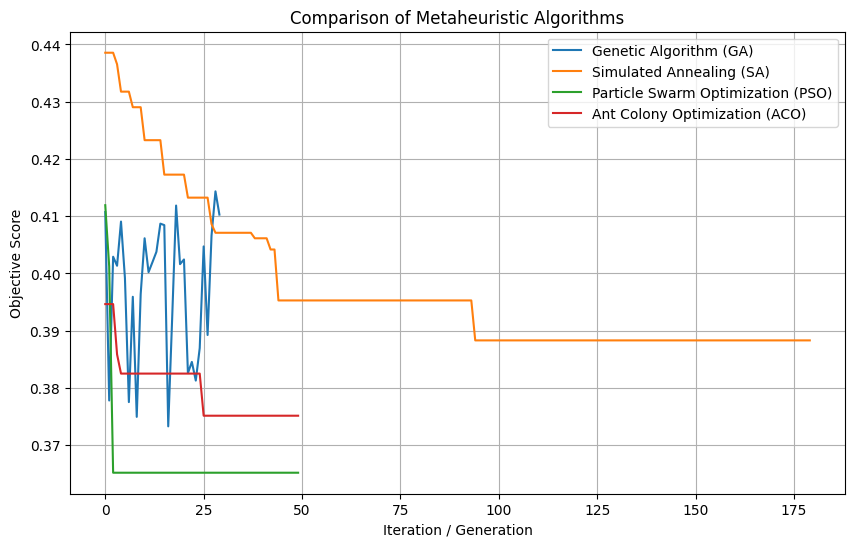

In [3220]:
plt.figure(figsize=(10,6))

plt.plot(history_GA, label="Genetic Algorithm (GA)")
plt.plot(history_SA, label="Simulated Annealing (SA)")
plt.plot(history_PSO, label="Particle Swarm Optimization (PSO)")
plt.plot(history_ACO, label="Ant Colony Optimization (ACO)")

plt.xlabel("Iteration / Generation")
plt.ylabel("Objective Score")
plt.title("Comparison of Metaheuristic Algorithms")

plt.legend()
plt.grid(True)

plt.show()

In [3213]:
# =========================================
# ใช้ผลลัพธ์จาก algorithm ที่ดีที่สุด = PSO
# =========================================

best_solution = best_PSO

# -----------------------------------------
# function สร้างตารางเดินรถ
# -----------------------------------------

def generate_schedule(route_name, route_stops, num_bus, cycle_time, start_time=7 * 60 + 15):
    """
    start_time = 07:00
    cycle_time = เวลาวิ่งครบ loop (minutes)
    """
    headway = cycle_time / num_bus
    segments = len(route_stops) - 1
    time_per_stop = cycle_time / segments

    schedules = []

    for bus_id in range(num_bus):
        depart_time = start_time + (bus_id * headway)

        stop_times = []

        for i, stop in enumerate(route_stops):
            arrival = depart_time + (i * time_per_stop)

            hour = int(arrival // 60)
            minute = int(arrival % 60)

            stop_times.append({
                "stop": stop,
                "time": f"{hour:02d}:{minute:02d}"
            })

        schedules.append({
            "bus": f"{route_name}-Bus-{bus_id + 1}",
            "schedule": stop_times
        })

    return schedules


# -----------------------------------------
# สร้าง schedule จาก PSO
# -----------------------------------------

all_schedules = []

for idx, route in enumerate(best_solution, start=1):

    route_name = f"Route-{route['route_id']}"
    route_stops = route["path"]
    num_bus = 5

    # คำนวณ cycle time จาก graph
    cycle_time = calculate_cycle_time(
        route_stops,
        G
    )

    schedule = generate_schedule(
        route_name=route_name,
        route_stops=route_stops,
        num_bus=num_bus,
        cycle_time=cycle_time,
        start_time=7 * 60 + 15   # 07:15
    )

    all_schedules.append({
        "route_id": route["route_id"],
        "path": route_stops,
        "num_bus": num_bus,
        "cycle_time": cycle_time,
        "schedule": schedule
    })

In [3214]:
# -----------------------------------------
# print ตารางเดินรถ
# -----------------------------------------

print("===== BUS SCHEDULE FROM BEST PSO =====\n")

with open("bus_schedule.txt", "w", encoding="utf-8") as f:
    for route_data in all_schedules:

        print(f"Route ID: {route_data['route_id']}")
        print(f"Path: {' -> '.join(route_data['path'])}")
        print(f"Num Bus: {5}")
        print(f"Cycle Time: {route_data['cycle_time']} min")
        print("-" * 50)

        for bus in route_data["schedule"]:

            f.write(bus["bus"] + "\n")

            for stop in bus["schedule"]:

                f.write(

                    f"   {stop['stop']:15} : {stop['time']}\n"

                )

            f.write("\n")

        f.write("=" * 70 + "\n")

===== BUS SCHEDULE FROM BEST PSO =====

Route ID: 1
Path: Convention -> Terminal -> SC2_SC3 -> Library -> Dorm -> Convention
Num Bus: 5
Cycle Time: 22 min
--------------------------------------------------


14

27

27

27

...

27

27

27

1

71